# Data Analysis project
## Spotify songs Dataset

### EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume

## Data loading  
In the following project we will analyse a dataset with several data about some songs listened on Spotify.  
For each song we have the following variables :
- track_id
- track_name
- track_artist
- track_popularity : a grade between 0 and 100
- track_album_id : the id of the album of the track
- track_album_name
- track_album_release_date
- playlist_name
- playlist_genre
- danceability : float between 0 and 1 to quantify if the track is danceable, based on some criterion like tempo, rhythm stability, beat strength, and overall regularity
-  energy : float between 0 and 1 representing a perceptual measure of intensity and activity
-  key : estimated key of the track, 0=C, 1=C#, 2=D ... -1=no key detected
-  loudness : overall loudness in average of a track in decibels (dB), represents the quality of a sound
-  mode : modality of a track : major = 1, minor = 0
-  speechiness : float between 0 and 1 indicating the presence of spoken word in a track >2/3 : almost only spoken words, 1/3< <2/3 : contains both music and speech, <1/3 : music and non-speech-like tracks
-  acousticness : float between 0 and 1 describing if the song is accoustic
-  instrumentalness : float between 0 and 1 representing if the track is more vocal : close to 0 or intrumental : close to 1
-  liveness : float between 0 and 1 detecting the presence or not of an audience. Above 0.8 the track is probably a live
-  valence :  a float between 0 and 1 mesuring the positiveness of a song (close to 1)
-  tempo : tempo in beats per minute (BPM)
-  duration_ms


Possibilités de faires des categories pour key (enfin c'en est deja une), speechiness, liveness, tempo

In [1]:
#pip install prince

In [2]:
#pip install datasets

In [42]:
import pandas as pd
import numpy as np
import prince
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
# from datasets import load_dataset

In [4]:
song = pd.read_csv("spotify_songs.csv")

In [5]:
song.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


Cleaning data : removing useless columns

In [6]:
song.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

Track_id, track_name, playlist_id, track_album_id are identifier variables that have no purpose for clustering or inference, thus we will delete them from our dataframe. 

In [7]:
song.drop('track_id', axis = 1, inplace = True)
song.drop('track_name', axis = 1, inplace = True)
song.drop('playlist_id', axis = 1, inplace = True)
song.drop('track_album_id', axis = 1, inplace = True)

Changing release date to only keep the year. Indeed, the exact release date has no purpose for clustering or inference, but we will get more overall information only keeping the year and the month (we will be able to see if one genre of music was trendy for a given year for instance, or if some songs are more popular in summer).

Problem here : time data does not always have the same format : example 2012, 2012-07... We choose to keep everything and set month to 0 if we do not have the info.

In [8]:
from datetime import datetime
#print(song['track_album_release_date'])
years = []
months = []
#print(song.size)
for i in range(song.shape[0]):
    #print(song['track_album_release_date'][i])
    #print(i)
    if((len(song['track_album_release_date'][i]))==4):
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y').year)
        months.append(0)
    elif((len(song['track_album_release_date'][i]))==7):
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m').year)
        months.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m').month)
    else:
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m-%d').year)
        months.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m-%d').month)
song['track_album_release_year'] = pd.Series(years)
song['track_album_release_month'] = pd.Series(months)

Removing track album release date (which is now a bit redundant with the new columns for release year and month)

In [9]:
song.drop('track_album_release_date', axis = 1, inplace = True)

Factoring categorial variables + changing the unit of duration

In [10]:
song['track_artist'] = song['track_artist'].astype('category')
song['track_album_name'] = song['track_album_name'].astype('category')
song['playlist_name'] = song['playlist_name'].astype('category')
song['playlist_genre'] = song['playlist_genre'].astype('category')
song['playlist_subgenre'] = song['playlist_subgenre'].astype('category')
song['mode'] = song['mode'].astype('category')
song['track_album_release_year'] = song['track_album_release_year'].astype('category')
song['track_album_release_month'] = song['track_album_release_month'].astype('category')
song['key'] = song['key'].astype('category')
song['duration_s']=song['duration_ms']/1000
song.drop('duration_ms',axis =1,inplace=True)

Columns containing missing values

In [11]:
print('Columns containing missing values are : ', list(song.columns[song.isnull().sum()!=0]))

Columns containing missing values are :  ['track_artist', 'track_album_name']


Track artist

In [12]:
print("Track artist - Rate of missing values: {:.2f}%".format(song['track_artist'].isnull().sum()/song.shape[0]*100))

Track artist - Rate of missing values: 0.02%


The rate of missing values for track artist variable is really low, it makes no sense to remove the variable nor to set it to the most common track artist, we will thus keep it the way it is.

In [13]:
print("Track album name - Rate of missing values: {:.2f}%".format(song['track_album_name'].isnull().sum()/song.shape[0]*100))

Track album name - Rate of missing values: 0.02%


Same conclusion with track album name than with the track artist variable. So we will delete the rows containing missing values as they will not be able to provide information.

In [14]:
nb_mv_key = 0
for i in range(song.shape[0]):
    if(song['key'][i] == -1):
        nb_mv_key += 1
print("Key - Number of missing values : {:.2f}".format(nb_mv_key))

Key - Number of missing values : 0.00


We basically have no missing values for the $key$ variable, no need to change anything.

We have to be careful because variable $track\_album\_release\_month$ do have missing values, even though those are not
set to null but 0. Thus we still have to check their rate of missing values.

In [15]:
rate_mv_tarm = 0
for i in range(song.shape[0]):
    if(song['track_album_release_month'][i] == 0):
        rate_mv_tarm += (1/song.shape[0])
print("Track album release month - Rate of missing values : {:.2f}%".format(rate_mv_tarm*100))

Track album release month - Rate of missing values : 5.65%


We have a lot of missing values for track album release month. We still have not decided what to do with this.

In [16]:
song.dropna(axis=0, inplace = True)

## Overview on the dataset

In [17]:
song.describe()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
count,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000
mean,42.483551,0.654850,0.698603,-6.719529,0.107053,0.175352,0.084760,0.190175,0.510556,120.883642,225.796830
std,24.980476,0.145092,0.180916,2.988641,0.101307,0.219644,0.224245,0.154313,0.233152,26.903632,59.836492
min,0.000000,0.000000,0.000175,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,24.000000,0.563000,0.581000,-8.171250,0.041000,0.015100,0.000000,0.092700,0.331000,99.961000,187.804500
50%,45.000000,0.672000,0.721000,-6.166000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216.000000
75%,62.000000,0.761000,0.840000,-4.645000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918250,253.581250
max,100.000000,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517.810000


Shorter music : 4s, many zeros values => outliers ?, remove some individuals ?

We have a good representation of each genre (at least 5000 titles), thus it will be interesting to study the genre of a music depending of some other parameters.

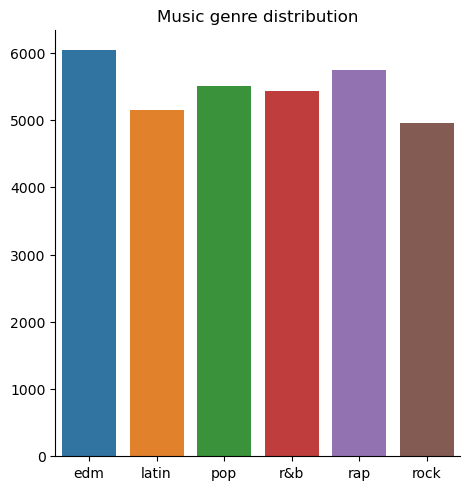

In [18]:
# genre distribution
fig = sns.catplot(data=song, x='playlist_genre', kind='count', hue='playlist_genre')

plt.xlabel('')
plt.ylabel('')
plt.title('Music genre distribution')
plt.show()


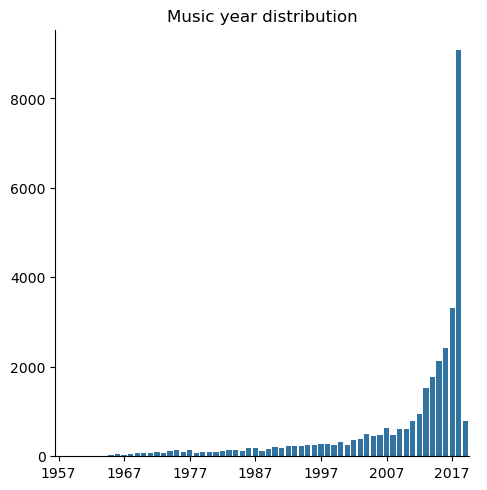

In [19]:
# year of release distribution
fig = sns.catplot(data=song, x='track_album_release_year', kind='count')

plt.xlabel('')
plt.ylabel('')
plt.title('Music year distribution')

xticks = plt.xticks()[0]
plt.xticks(ticks=xticks[::10], labels=[int(t)+min(song['track_album_release_year']) for t in xticks[::10]])
plt.show()

We have more recent musics in the dataset and especialy for 2018 

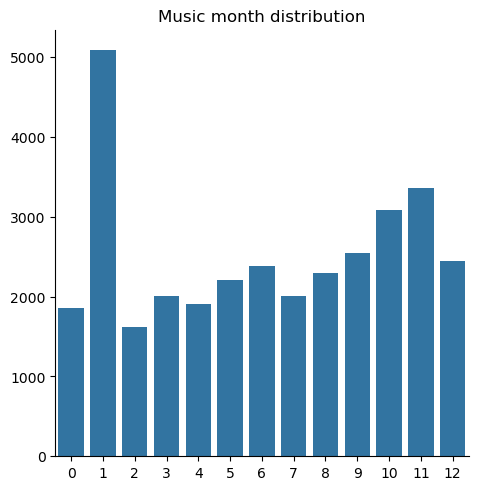

In [20]:
# month of release distribution
fig = sns.catplot(data=song, x='track_album_release_month', kind='count')

plt.xlabel('')
plt.ylabel('')
plt.title('Music month distribution')

xticks = plt.xticks()[0]
plt.xticks(ticks=xticks[::1], labels=[int(t)+min(song['track_album_release_month']) for t in xticks[::1]])
plt.show()

We can see a lot of albums are released in January, this can be explained by the fact that labels produced Christmas songs in Nov/Dec and don't have the time and money for others and also the artists are waiting January not to compete with Christmas songs.
We decide to put the missing monthes to January.

In [21]:
song['track_album_release_month'].replace(0,1,inplace=True)

/tmp/ipykernel_31933/2524397391.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  song['track_album_release_month'].replace(0,1,inplace=True)
/tmp/ipykernel_31933/2524397391.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  song['track_album_release_month'].replace(0,1,inplace=True)


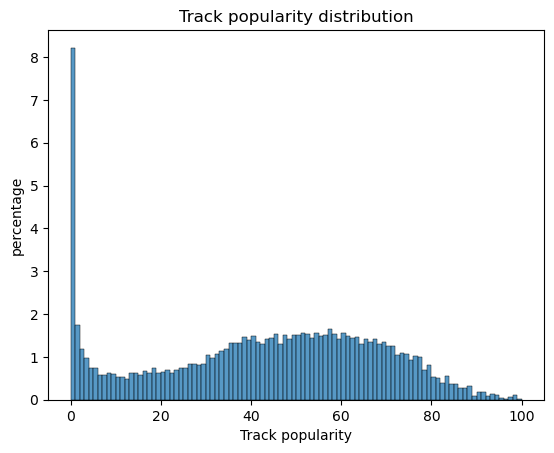

In [22]:
# track popularity distribution
fig=sns.histplot(data=song,x='track_popularity',bins=100,stat='percent')
plt.xlabel('Track popularity')
plt.ylabel('percentage')
plt.title('Track popularity distribution')
plt.show()

We observe a large number of unpopular tracks. This is understandable for new/unknown artists for which the score calculated by Spotify is obviously low even if the music could be good as the score is highly based on the number of streams. After this high number of unpopular tracks between 0 and 5, we can observe a gaussian with mean around 55.

In [23]:
#plt.figure(1)
#mgc=song['playlist_genre'].value_counts(sort=False)
#mg=np.array(song['playlist_genre'].unique()).sort()
#ydc=song['track_album_release_year'].value_counts(sort=True)
#yd=np.array(song['track_album_release_year'].unique()).sort()
#fig, axs = plt.subplots(4, 5, figsize=(20,15))
#axs[0,0].bar(mg,height=mgc)
#axs[0,1].hist(yd)
#plt.show()

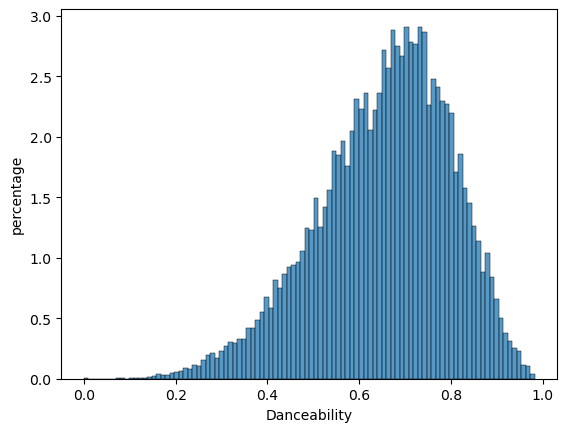

In [24]:
# danceability distribution
fig=sns.histplot(data=song,x='danceability',bins=100,stat='percent')
plt.xlabel('Danceability')
plt.ylabel('percentage')
plt.title('')
plt.show()

We observe a gaussian distribution with a mean around 0.65. We conclude that the majority of the songs are danceable.

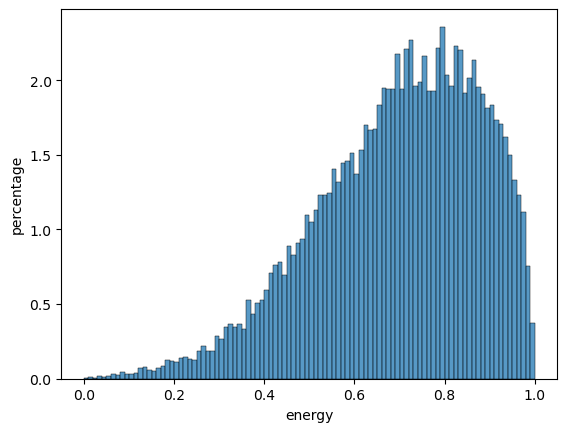

In [25]:
# danceability distribution
fig=sns.histplot(data=song,x='energy',bins=100,stat='percent')
plt.xlabel('energy')
plt.ylabel('percentage')
plt.title('')
plt.show()

Gaussian with high mean => lot of high energy songs

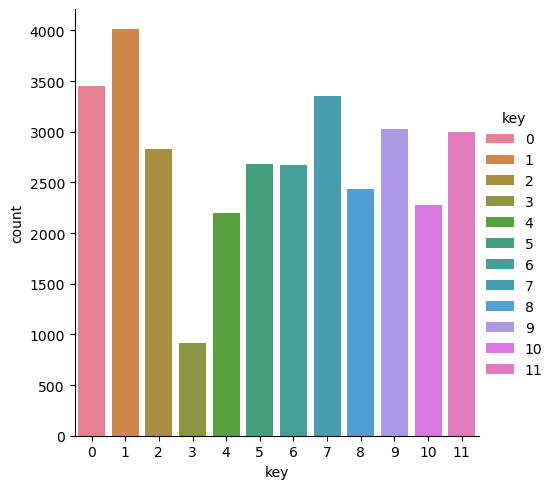

In [26]:
fig=sns.catplot(data=song,x='key',kind='count',hue='key')
plt.xlabel('key')
plt.ylabel('count')
plt.title('')
plt.show()

We observe that there is much less key 3 (D♯/E♭)than the others.

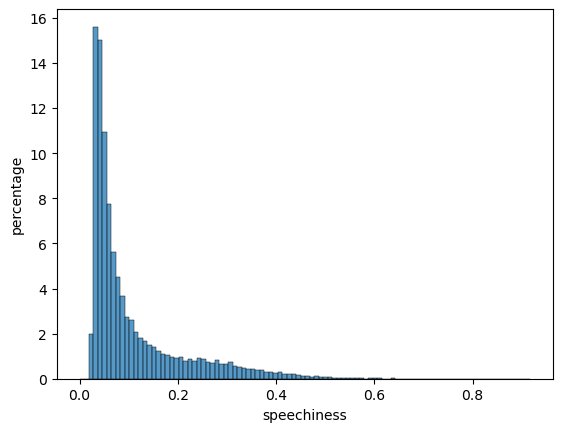

In [27]:
# danceability distribution
fig=sns.histplot(data=song,x='speechiness',bins=100,stat='percent')
plt.xlabel('speechiness')
plt.ylabel('percentage')
plt.title('')
plt.show()

Most songs contains more music than tracks 

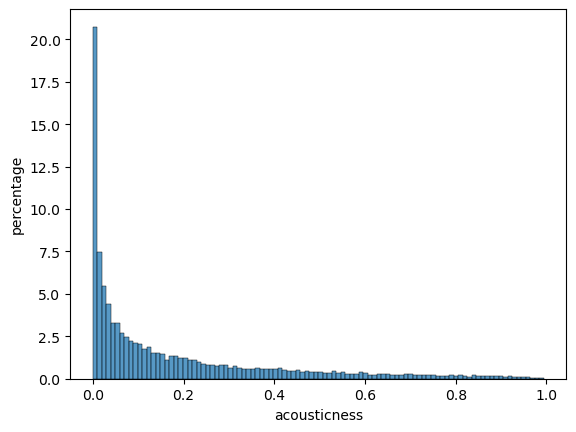

In [28]:
# danceability distribution
fig=sns.histplot(data=song,x='acousticness',bins=100,stat='percent')
plt.xlabel('acousticness')
plt.ylabel('percentage')
plt.title('')
plt.show()

most songs have a low acousticness

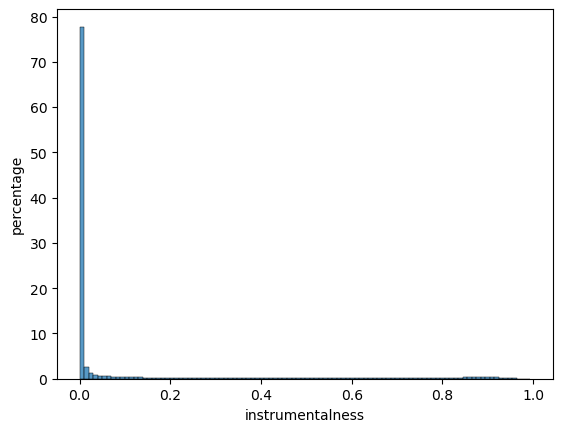

In [29]:
fig=sns.histplot(data=song,x='instrumentalness',bins=100,stat='percent')
plt.xlabel('instrumentalness')
plt.ylabel('percentage')
plt.title('')
plt.show()

most songs are fully vocal (maybe not interesting to analyze)

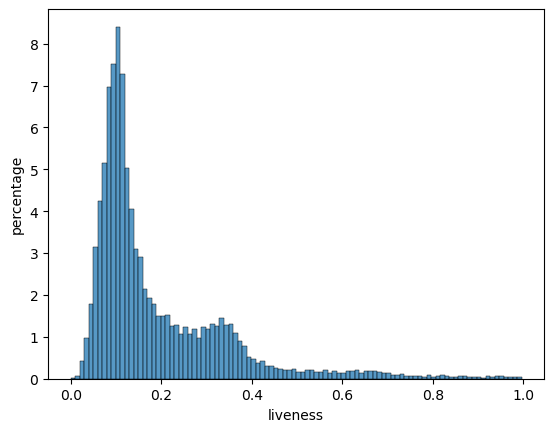

In [30]:
fig=sns.histplot(data=song,x='liveness',bins=100,stat='percent')
plt.xlabel('liveness')
plt.ylabel('percentage')
plt.title('')
plt.show()

most songs are recorded without an audience

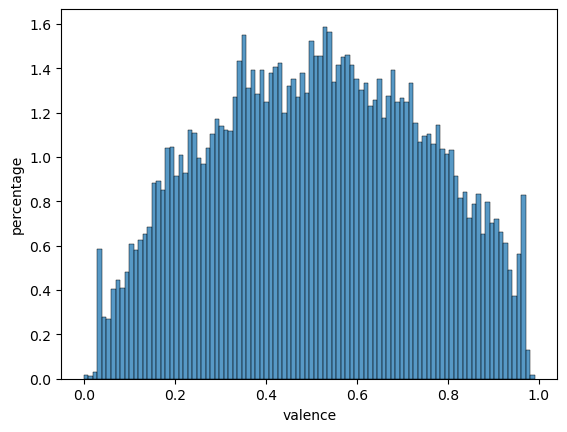

In [31]:
fig=sns.histplot(data=song,x='valence',bins=100,stat='percent')
plt.xlabel('valence')
plt.ylabel('percentage')
plt.title('')
plt.show()

Nice gaussian

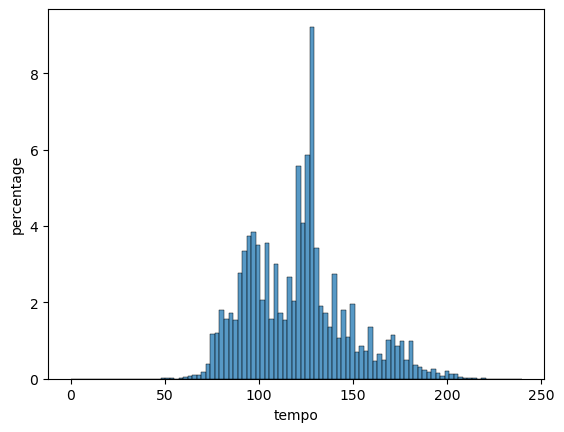

In [32]:
fig=sns.histplot(data=song,x='tempo',bins=100,stat='percent')
plt.xlabel('tempo')
plt.ylabel('percentage')
plt.title('')
plt.show()

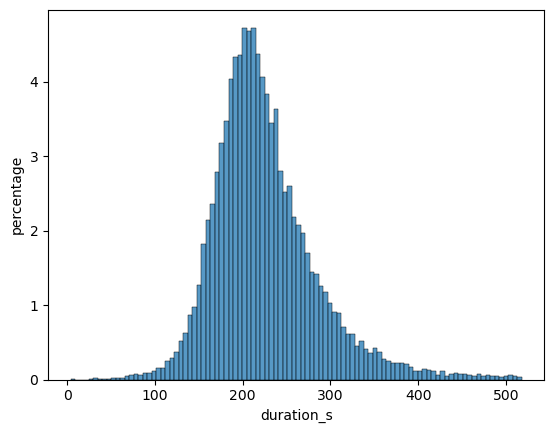

In [33]:
fig=sns.histplot(data=song,x='duration_s',bins=100,stat='percent')
plt.xlabel('duration_s')
plt.ylabel('percentage')
plt.title('')
plt.show()

nice gaussian

### Bidimensionnal analysis

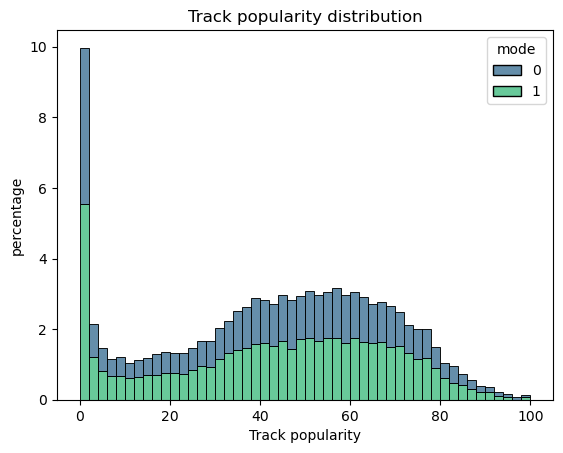

In [34]:
# track popularity distribution
fig=sns.histplot(data=song,x='track_popularity',bins=50,stat='percent', hue='mode', multiple="stack", palette='viridis')
plt.xlabel('Track popularity')
plt.ylabel('percentage')
plt.title('Track popularity distribution')
plt.show()

We can clearly see that the dominant mode is the major one, but follows the distribution of the track popularity, hence it does not seem to affect it.

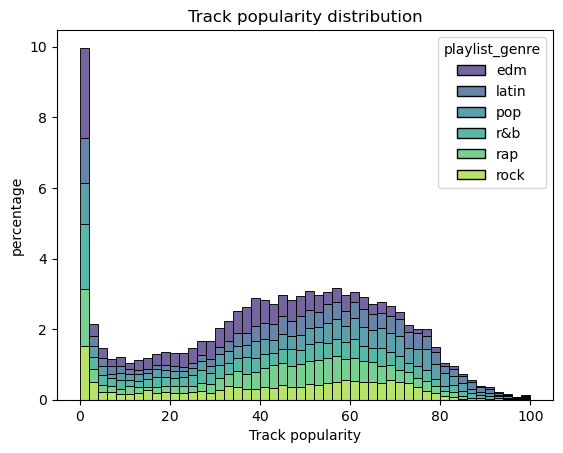

In [35]:
# track popularity distribution
fig=sns.histplot(data=song,x='track_popularity',bins=50,stat='percent', hue='playlist_genre', multiple="stack", palette='viridis')
plt.xlabel('Track popularity')
plt.ylabel('percentage')
plt.title('Track popularity distribution')
plt.show()

We notice that the genre EDM is the most impopular genre, having the most of occurences having 0 popularity score. Moreover, EDM has only a few tracks being popular compared to the other genres. The rap music seems to be most represented at around 50 popularity score, meaning rap musics are often popular, but to a specific part of the population.

In [38]:
song_quanti = song.select_dtypes(include=['float64', 'int64'])

In [37]:
song_quanti.head()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,66,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194.754
1,67,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162.600
2,70,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176.616
3,60,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169.093
4,69,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189.052


In [45]:
pca = PCA(n_components=11)
pca.fit(song_quanti)

PCA(n_components=11)

In [50]:
var_exp_ratio = np.cumsum(pca.explained_variance_ratio_)

In [54]:
var_exp_ratio

array([0.72832528, 0.8749636 , 0.99818649, 0.99995686, 0.99996945,
       0.99997926, 0.99998749, 0.99999253, 0.99999617, 0.99999821,
       1.        ])